In [118]:
import os 
import optuna
import logging
import random
import datetime

import pandas as pd 
import numpy as np 
import yfinance as yf 
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy.cluster.hierarchy as sch 
import tensorflow as tf 
from tensorflow import keras #type: ignore 
from keras import layers
from scipy.spatial.distance import pdist 
from sklearn.preprocessing import StandardScaler
from arch import arch_model 

DATA_FINAL = datetime.datetime.now().strftime('2026-04-13')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Configuração do modelo --- 
seed_value = 42 
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

CAPITAL_DISPONIVEL = 1_000_000

# --- Carregamento e tratamento dos dados ---

etfs_dict = {
    'Emergents': ['IEMG', 'VWO'],
    'Energy': ['XLE'],
    'Defense': ['ITA'],
    'Strategic_Commodities': ['REMX'],
    'Tech': ['VGT', 'XLK', 'QQQ'],
    'Biotech': ['XBI', 'XLV'],
    'Small Caps': ['VBR'],
    'International': ['EXUS'],
    'Gold': ['IAU'],
    'Alternatives': ['DBMF']
}

all_etfs = [item for sublist in etfs_dict.values() for item in sublist]

raw_data = yf.download(all_etfs, start='2014-01-01', end=DATA_FINAL, auto_adjust=True) 

#Tempo de 10-11 anos para, além de garantir a alta liquide.z, 
#analisa-se e surfa diversos períodos e ciclos econômicos

close_df = raw_data['Close'].copy().ffill()
close_df = close_df.dropna(how='all')

volume_df = raw_data['Volume'].copy().ffill()

valid_etfs = []
MIN_DAYS_HISTORY = 252 

#Para uma aplicação correta do HRP, aplica-se um filtro de pelo menos 1 ano útil de negociações.
# Sua utilização se deve, pois nem todas as empresas podem estar listadas desde o período inicial de dados. 

MIN_ADTV = 10_000_000

for t in all_etfs:
    if t not in close_df.columns or t not in volume_df.columns:
        continue
    if close_df[t].dropna().shape[0] < MIN_DAYS_HISTORY:
        print(f'ETF {t} foi rejeitado: Histórico de tempo muito curto')
        continue

    precos_recentes = close_df[t].iloc[-21:]
    volumes_recentes = volume_df[t].iloc[-21:]

    adtv_21 = (precos_recentes * volumes_recentes).mean()
    
    if not t.endswith('=X'): # Ignora moedas, que não têm volume padrão
        if pd.isna(adtv_21) or adtv_21 < MIN_ADTV:
            print(f'ETF {t} rejeitado: Baixa Liquidez (Calculado: {adtv_21})')
            continue
            
    valid_etfs.append(t)

print(f"ETFs validados: {valid_etfs}")

clean_close = close_df[valid_etfs].copy()
clean_ret_log = np.log(clean_close/clean_close.shift(1))

for t in valid_etfs:
    media = clean_ret_log[t].mean()
    desvio = clean_ret_log[t].std()
    limite_superior = media + (4 * desvio)
    limite_inferior = media - (4 * desvio)

    clean_ret_log[t] = clean_ret_log[t].clip(lower=limite_inferior, upper=limite_superior)
print('Coleta e Análise de Dados do Portfólio Concluída')

[*********************100%***********************]  14 of 14 completed

ETF EXUS foi rejeitado: Histórico de tempo muito curto
ETFs validados: ['IEMG', 'VWO', 'XLE', 'ITA', 'REMX', 'VGT', 'XLK', 'QQQ', 'XBI', 'XLV', 'VBR', 'IAU', 'DBMF']
Coleta e Análise de Dados do Portfólio Concluída


In [119]:
# --- Configurações do Modelo E-GARCH --- 
egarch_volatility = pd.DataFrame()

#Usando valid_etfS e clean_ret_log para cálculo e previsão da volatilidade:
for t in valid_etfs: 
    try: 
        returns = 100 * clean_ret_log[t].dropna()
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
        res = am.fit(update_freq=5, disp='off')
        egarch_volatility[t] = res.conditional_volatility / 100
    except: continue

egarch_volatility = egarch_volatility.dropna()
egarch_volatility


,IEMG,VWO,XLE,ITA,REMX,VGT,XLK,QQQ,XBI,XLV,VBR,IAU,DBMF
Date,,,,,,,,,,,,,
2019-05-09,0.012178,0.011925,0.012044,0.010850,0.018298,0.010710,0.010778,0.011078,0.020654,0.009866,0.010072,0.006104,0.006024
2019-05-10,0.013569,0.012900,0.011448,0.010354,0.017481,0.011076,0.011130,0.011229,0.019929,0.009545,0.009806,0.006102,0.005562
2019-05-13,0.012801,0.012337,0.011089,0.009950,0.016950,0.010487,0.010491,0.010492,0.019502,0.008941,0.009347,0.005983,0.005153
2019-05-14,0.016818,0.016100,0.012234,0.012962,0.019062,0.016827,0.016995,0.016672,0.022930,0.011254,0.012813,0.006476,0.005630
2019-05-15,0.015933,0.015385,0.012155,0.012525,0.019383,0.016088,0.016232,0.015566,0.022143,0.010581,0.012258,0.006328,0.005899
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,0.017255,0.014681,0.014932,0.018829,0.031280,0.017727,0.018034,0.014759,0.019773,0.010669,0.011592,0.019297,0.007474
2026-04-07,0.016130,0.013782,0.014460,0.018062,0.029810,0.016508,0.016726,0.013751,0.019037,0.010453,0.011011,0.018343,0.007300
2026-04-08,0.014930,0.012911,0.014053,0.017945,0.028554,0.015365,0.015532,0.012763,0.018231,0.009793,0.010425,0.017948,0.006721


In [120]:
# --- Features --- 
# A função .tz_localize vai remover a diferença de fuso entre os dados.

print("Baixando os dados OHLCV para os indicadores técnicos do modelo")

ohlcv = yf.download(valid_etfs, start='1998-12-16', end=DATA_FINAL, auto_adjust=True)
ohlcv.index = ohlcv.index.tz_localize(None)
clean_close.index = clean_close.index.tz_localize(None)

print("Baixando Leading Indicators Globais (VIX e Juros 10A)...")
macro_tickers = ['^VIX', '^TNX']
macro_data = yf.download(macro_tickers, start='2015-01-01', end=DATA_FINAL, auto_adjust=True)['Close']
macro_data = macro_data.ffill()
macro_data.index = macro_data.index.tz_localize(None) # Removendo fuso
macro_data['VIX_Change'] = np.log(macro_data['^VIX'] / macro_data['^VIX'].shift(1)) 
macro_data['TNX_Change'] = macro_data['^TNX'].diff()

print("Baixando Benchmark para Performance Relativa...")
benchmark = yf.download('IVV', start='1998-12-16', end=DATA_FINAL, auto_adjust=True)['Close']
benchmark = benchmark.ffill()
benchmark.index = benchmark.index.tz_localize(None)

panel = []
print("Construindo Painel Neural com Sistema de Pontuação...")

for t in valid_etfs:
    try: 
        if t not in egarch_volatility.columns: continue

        df = clean_close[[t]].copy()
        df.columns = ['Close']
        df = df.dropna()
        df['ticker'] = t

        # --- 1. DADOS EXTRAS PARA INDICADORES ---
        df['ret_log'] = clean_ret_log[t]
        df['High'] = ohlcv['High'][t]
        df['Low'] = ohlcv['Low'][t]
        df['Volume'] = ohlcv['Volume'][t]

        # --- 2. CÁLCULO DOS INDICADORES TÉCNICOS ---
        # RSI (14 days)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-8)
        df['RSI'] = 100 - (100 / (1 + rs))

        # EMAs e MAs
        df['EMA_9'] = df['Close'].ewm(span=9, adjust=False).mean()
        df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
        df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
        df['MA_50'] = df['Close'].rolling(window=50).mean()

        # MACD
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_hist'] = df['MACD'] - df['MACD_signal']

        # Volume Ratio e Momentum
        df['Volume_ratio'] = df['Volume'] / (df['Volume'].rolling(window=20).mean() + 1e-8)
        df['Price_momentum_1d'] = df['Close'].pct_change() # 24h momentum adaptado para diário

        # Estocástico (Stoch_K)
        low_14 = df['Low'].rolling(window=14).min()
        high_14 = df['High'].rolling(window=14).max()
        df['Stoch_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14 + 1e-8))
        """
        # Performance Relativa
        df['Relative_Ratio'] = df['ret_log'] - benchmark_ret_log
        df['Rel_Ratio_SMA'] = df['Relative_Ratio'].rolling(window=20).mean()
        df.loc[df['Relative_Ratio'] > df['Rel_Ratio_SMA'], 'points_buy'] += 20 
        df.loc[df['Relative_Ratio'] < df['Rel_Ratio_SMA'], 'points_buy'] -= 10
        """
        # --- 3. SISTEMA DE PONTOS (A SUGESTÃO DA ORTOGONALIZAÇÃO) ---
        df['points_buy'] = 0
        
        df.loc[df['RSI'] <= 30, 'points_buy'] += 20
        df.loc[(df['RSI'] > 30) & (df['RSI'] <= 40), 'points_buy'] += 10
        df.loc[df['RSI'] > 50, 'points_buy'] += 10
        
        ema_bullish = (df['EMA_9'] > df['EMA_50']) & (df['EMA_21'] > df['EMA_50'])
        df.loc[ema_bullish, 'points_buy'] += 15
        
        df.loc[df['MACD'] > 0, 'points_buy'] += 15
        
        macd_growing = df['MACD_hist'] > df['MACD_hist'].shift(1)
        df.loc[macd_growing, 'points_buy'] += 5
        
        df.loc[df['Volume_ratio'] >= 1.5, 'points_buy'] += 15
        df.loc[df['Price_momentum_1d'] > 0.02, 'points_buy'] += 5
        df.loc[df['Stoch_K'] <= 20, 'points_buy'] += 5

        # (Bandas de Bollinger foram removidas do modelo)
        # Por que? Elas assumem que os retornos são distribuições normais,
        # o que realmente não acontece. 

        # --- 4. TRIGGER DE VENDA SIMPLIFICADO ---
        ema9_above_ma50_prev = df['EMA_9'].shift(1) > df['MA_50'].shift(1)
        ema9_below_ma50_now = df['EMA_9'] <= df['MA_50']
        # Convertendo o booleano (True/False) para número (1/0) para a IA entender
        df['sell_trigger'] = (ema9_above_ma50_prev & ema9_below_ma50_now).astype(int) 

        # --- 5. RISCO E MACRO (Blindagem do Fundo) ---
        df['egarch_vol'] = egarch_volatility[t]
        df = df.join(macro_data[['VIX_Change', 'TNX_Change']], how='inner')

        # --- 6. TARGET MACHINE LEARNING ---
        df['target_weekly'] = np.log(df['Close'].shift(-5) / df['Close'].shift(-1))
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except Exception as e: 
        print(f'Erro no ETF {t}: {e}')
        continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

# A Inteligência Artificial agora cruza o seu Sistema de Pontos com a Macroeconomia
train_data = data[data.index < '2024-12-31']
val_data = data[(data.index >= '2025-01-01') & (data.index < data.index.max())]

features = ['points_buy', 'sell_trigger', 'egarch_vol', 'VIX_Change', 'TNX_Change']

# --- PREPARAÇÃO DE DADOS (Corte Cronológico TRAIN / VAL) ---
train_data = data[data.index < '2024-12-31']
val_data = data[(data.index >= '2025-01-01') & (data.index < data.index.max())]

latest_date = data.index.max()
train_data = data[data.index < latest_date].copy()
latest_data = data[data.index == latest_date].copy()

# 2. O Scaler aprende a média/desvio APENAS do passado (Alpha Puro)
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[features])
y_train = (train_data['rank_score'] > 0).astype(int).values

X_val = scaler.transform(val_data[features])
y_val = (val_data['rank_score'] > 0).astype(int).values

# 3. Guardamos os dados de hoje isolados para a inferência final
X_latest_alpha = scaler.transform(latest_data[features])

Baixando os dados OHLCV para os indicadores técnicos do modelo


[*********************100%***********************]  13 of 13 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


Baixando Leading Indicators Globais (VIX e Juros 10A)...
Baixando Benchmark para Performance Relativa...
Construindo Painel Neural com Sistema de Pontuação...


In [121]:
import xgboost as xgb
import optuna
from sklearn.metrics import accuracy_score

print("Iniciando a otimização de hiperparâmetros (XGBoost) com Optuna...")

def objective(trial):
    # Definimos o espaço de busca dos melhores parâmetros para o mercado
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    
    # Instancia e treina o modelo de árvore
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # Avalia a acurácia na base de validação (Fora da amostra)
    preds = model.predict(X_val)
    accuracy = accuracy_score(y_val, preds)
    return accuracy

# Executa 30 tentativas para achar a melhor árvore de decisão
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"\n✅ Melhor arquitetura encontrada:")
print(study.best_params)

Iniciando a otimização de hiperparâmetros (XGBoost) com Optuna...

✅ Melhor arquitetura encontrada:
{'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.19949460594729404, 'subsample': 0.7901344115758449, 'colsample_bytree': 0.879721214172534}



Treinando o Super Modelo XGBoost com todos os dados disponíveis...
✅ Modelo treinado com sucesso!


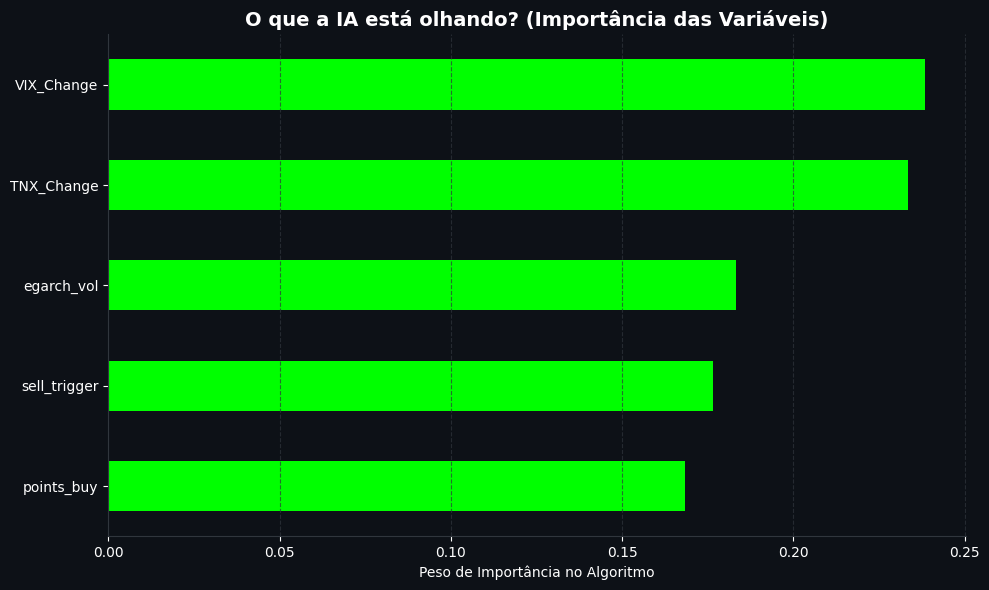

In [122]:
print("\nTreinando o Super Modelo XGBoost com todos os dados disponíveis...")

# Unimos Treino e Validação para o modelo final ter a "foto" mais recente do mercado
X_all = np.vstack((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

# Resgata os melhores parâmetros do Optuna
best_params = study.best_params
best_params['objective'] = 'binary:logistic'
best_params['random_state'] = 42

# Treina o modelo definitivo
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_all, y_all)

print("✅ Modelo treinado com sucesso!")

# --- PLOT: O CÉREBRO DA IA (Feature Importance) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Extrai o peso que a IA deu para cada indicador
importances = final_model.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=True)

# Gera um gráfico de barras estético
bars = feature_imp.plot(kind='barh', color='#00ff00', ax=ax, edgecolor='none')
ax.set_title("O que a IA está olhando? (Importância das Variáveis)", fontsize=14, fontweight='bold', color='white')
ax.set_xlabel("Peso de Importância no Algoritmo", fontsize=10, color='white')
ax.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)

for ax_obj in [ax]:
    ax_obj.spines['top'].set_visible(False)
    ax_obj.spines['right'].set_visible(False)
    ax_obj.spines['left'].set_color('#30363d')
    ax_obj.spines['bottom'].set_color('#30363d')

plt.tight_layout()
plt.show()

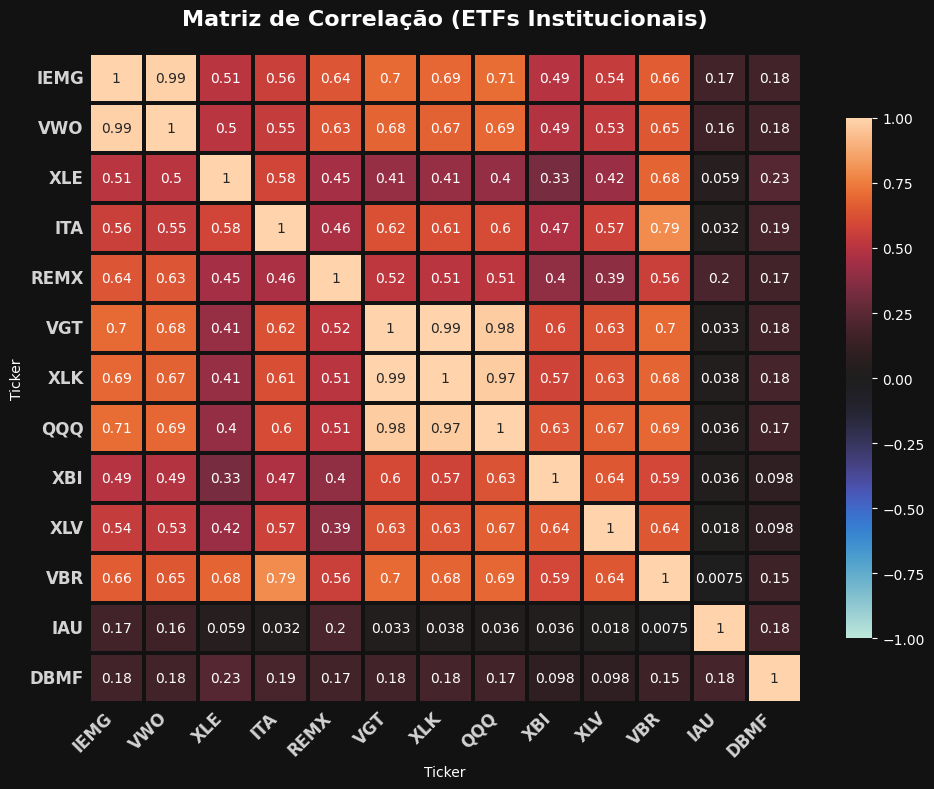

In [123]:
# --- Definindo a plotagem --- 
fig, ax = plt.subplots(figsize=(10, 8))
plt.style.use('dark_background')

bg_plot_color = '#121212' # Dark Bloomberg Theme
fig.patch.set_facecolor(bg_plot_color)
ax.set_facecolor(bg_plot_color)

# --- Correlação, Heatmap e Simulações de Monte Carlo
corr_matrix_etfs = clean_ret_log[valid_etfs].corr()
sns.heatmap(
    corr_matrix_etfs, 
    annot=True,
    #pmt = '.2f', # Para o HRP, 
    vmin=-1, vmax=1,
    center=0, 
    linewidths=1.5,
    linecolor=bg_plot_color, 
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de Correlação (ETFs Institucionais)', 
             fontsize=16, 
             fontweight='bold', 
             pad=20, 
             color='white')

plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='lightgray')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='lightgray')

ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [124]:
# --- Alocação ---

# PARÂMETROS 
ALPHA_POWER = 2.0  # Peso do sinal da IA
RISK_FLOOR = 0.05  # Piso de 5% de risco (Resolve o problema dos 96% no BIL)

# 2. MOTOR SIGMA: DOWNSIDE RISK MÓVEL (ROLLING WINDOW)
def get_rolling_downside_risk(ticker, window=252):
    # Pega apenas os últimos 252 dias de retorno até a data atual
    hist = clean_ret_log[ticker].tail(window)
    neg_rets = hist[hist < 0]
    if len(neg_rets) < 2: return RISK_FLOOR
    return neg_rets.std() * np.sqrt(252)

# 3. EXECUÇÃO DA ALOCAÇÃO
efficiency_scores = {}
print("Gerando Alocação:")

for ticker in valid_etfs:
    # Alpha: Previsão da IA (usando o scaler cego da Célula 3)
    ticker_feat = X_latest_alpha[latest_data['ticker'] == ticker]
    if len(ticker_feat) == 0:
        ai_alpha = 0.50
    else:
        ai_alpha = float(final_model.predict_proba(ticker_feat)[0][1])
    
    # SIGMA: Risco de queda móvel com Piso de Segurança
    raw_sigma = get_rolling_downside_risk(ticker)
    adjusted_sigma = max(raw_sigma, RISK_FLOOR) # Nivelamento para ativos ultra-seguros
    
    # EFICIÊNCIA FINAL
    score = (ai_alpha ** ALPHA_POWER) / (adjusted_sigma + 1e-6)
    efficiency_scores[ticker] = score
    
    print(f"{ticker:4} | Alpha: {ai_alpha:.4f} | Sigma: {raw_sigma*100:5.2f}% | Eficiência: {score:.2f}")

# 4. NORMALIZAÇÃO INSTITUCIONAL (CLIP 40%)
weights = pd.Series(efficiency_scores)
weights = weights / weights.sum()
weights = weights.clip(upper=0.40) # Evita concentração excessiva
weights /= weights.sum()

print("\n --- CARTEIRA FINAL ---")
for ticker, weight in weights.sort_values(ascending=False).items():
    print(f"{ticker}: {weight*100:.2f}%")

Gerando Alocação:
IEMG | Alpha: 0.8712 | Sigma: 13.48% | Eficiência: 5.63
VWO  | Alpha: 0.6212 | Sigma: 10.88% | Eficiência: 3.55
XLE  | Alpha: 0.8022 | Sigma: 15.34% | Eficiência: 4.20
ITA  | Alpha: 0.7689 | Sigma: 12.15% | Eficiência: 4.87
REMX | Alpha: 0.9295 | Sigma: 30.28% | Eficiência: 2.85
VGT  | Alpha: 0.7309 | Sigma: 15.61% | Eficiência: 3.42
XLK  | Alpha: 0.5694 | Sigma: 15.88% | Eficiência: 2.04
QQQ  | Alpha: 0.8174 | Sigma: 13.10% | Eficiência: 5.10
XBI  | Alpha: 0.9270 | Sigma: 16.64% | Eficiência: 5.16
XLV  | Alpha: 0.8320 | Sigma: 10.95% | Eficiência: 6.32
VBR  | Alpha: 0.9759 | Sigma: 10.86% | Eficiência: 8.77
IAU  | Alpha: 0.7977 | Sigma: 17.58% | Eficiência: 3.62
DBMF | Alpha: 0.3501 | Sigma:  9.40% | Eficiência: 1.30

 --- CARTEIRA FINAL ---
VBR: 15.43%
XLV: 11.12%
IEMG: 9.90%
XBI: 9.08%
QQQ: 8.97%
ITA: 8.56%
XLE: 7.38%
IAU: 6.37%
VWO: 6.24%
VGT: 6.02%
REMX: 5.02%
XLK: 3.59%
DBMF: 2.29%


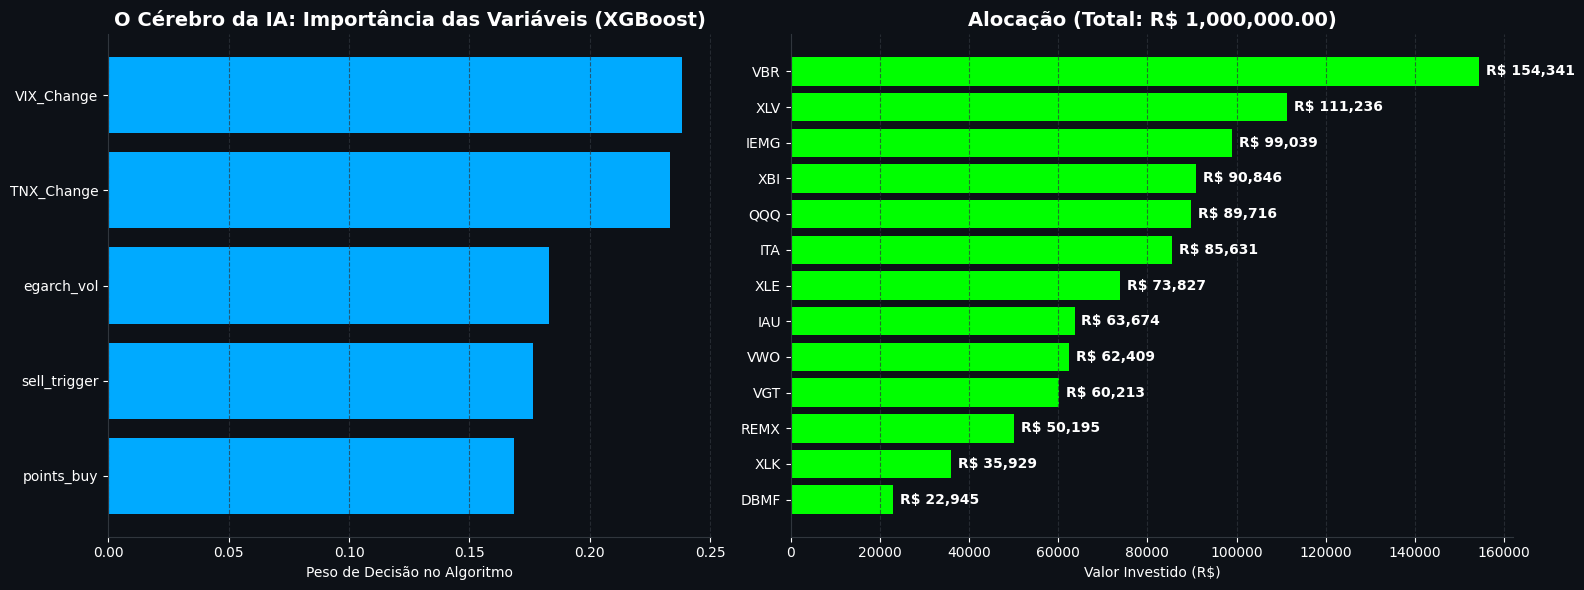

In [125]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#0d1117')
ax2.set_facecolor('#0d1117')

importances = final_model.feature_importances_
feature_imp = pd.Series(importances, index=features).sort_values(ascending=True)

ax1.barh(feature_imp.index, feature_imp.values, color='#00aaff', edgecolor='none')
ax1.set_title("O Cérebro da IA: Importância das Variáveis (XGBoost)", fontsize=14, fontweight='bold', color='white')
ax1.set_xlabel("Peso de Decisão no Algoritmo", fontsize=10, color='white')
ax1.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)

pesos_ordenados = weights.sort_values(ascending=True)
valores_financeiros = pesos_ordenados * CAPITAL_DISPONIVEL

bars2 = ax2.barh(pesos_ordenados.index, valores_financeiros.values, color='#00ff00', edgecolor='none')
ax2.set_title(f"Alocação (Total: R$ {CAPITAL_DISPONIVEL:,.2f})", fontsize=14, fontweight='bold', color='white')
ax2.set_xlabel("Valor Investido (R$)", fontsize=10, color='white')
ax2.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)

for bar in bars2:
    width = bar.get_width()
    ax2.annotate(f'R$ {width:,.0f}',
                 xy=(width, bar.get_y() + bar.get_height() / 2),
                 xytext=(5, 0),
                 textcoords="offset points",
                 ha='left', va='center', fontsize=10, color='white', fontweight='bold')
                 
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#30363d')
    ax.spines['bottom'].set_color('#30363d')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

Iniciando Backtest Out-of-Sample de 2024-12-31 até 2026-04-10...


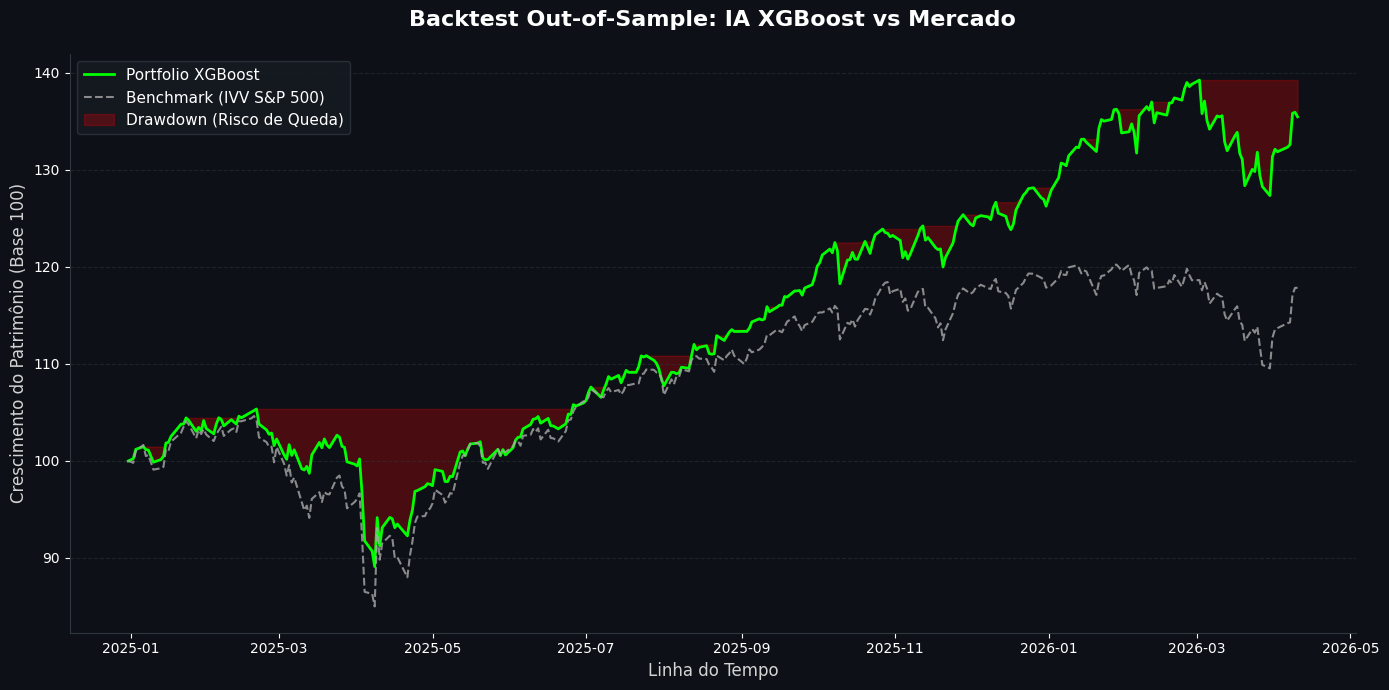

📊 PERFORMANCE REAL (Livre de Leakage)
Retorno Total:             35.45%
Retorno Anualizado:        27.09%
Volatilidade Anual (σ):    15.57%
Max Drawdown:             -15.42%
Sharpe Ratio:               1.74


In [ ]:
# ====================================================================
# CORREÇÃO DE DATAS (Definindo o Fatiamento Out-of-Sample)
# ====================================================================
# Define o início do período de testes
SPLIT_DATE = '2024-12-31'
DATA_FINAL = clean_ret_log.index.max().strftime('%Y-%m-%d')

print(f"Iniciando Backtest Out-of-Sample de {SPLIT_DATE} até {DATA_FINAL}...")

# ====================================================================
# 1. CÁLCULO DE RETORNOS DA ESTRATÉGIA
# ====================================================================
# Filtramos a base de retornos apenas para o período que a IA não viu
oos_returns_log = clean_ret_log.loc[SPLIT_DATE:]

# Multiplicamos os retornos diários pelos pesos definidos pelo modelo Alpha-Sigma
portfolio_returns = oos_returns_log[weights.index].mul(weights).sum(axis=1)

# Evolução do patrimônio (Base 100)
cumulative_port = np.exp(portfolio_returns.cumsum()) * 100

# ====================================================================
# 2. Benchmark e Drawdown
# ====================================================================
# Baixa o S&P 500 para comparação justa no mesmo período
benchmark_raw = yf.download('IVV', start=SPLIT_DATE, end=DATA_FINAL, auto_adjust=True, progress=False)['Close']
benchmark_ret = np.log(benchmark_raw / benchmark_raw.shift(1)).dropna()

# Alinhamento de calendário (Garante que os feriados batam com nossa carteira)
benchmark_ret = benchmark_ret.reindex(portfolio_returns.index).fillna(0)
cumulative_bench = np.exp(benchmark_ret.cumsum()) * 100

# CÁLCULO DO DRAWDOWN (Para o gráfico estilo Institucional)
running_max = cumulative_port.cummax()
drawdown = (cumulative_port / running_max) - 1

# ====================================================================
# 3. Plotagem
# ====================================================================
plt.figure(figsize=(14, 7))
plt.style.use('dark_background')

fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Linhas de Patrimônio
ax.plot(cumulative_port.index, cumulative_port, label='Portfolio XGBoost', color='#00ff00', linewidth=2)
ax.plot(cumulative_bench.index, cumulative_bench, label='Benchmark (IVV S&P 500)', color='#a9a9a9', linestyle='--', linewidth=1.5, alpha=0.8)

# Preenchimento Vermelho do Drawdown (A grande sacada visual)
ax.fill_between(cumulative_port.index, cumulative_port, running_max, color='red', alpha=0.25, label='Drawdown (Risco de Queda)')

plt.title(f'Backtest Out-of-Sample: IA XGBoost vs Mercado', fontsize=16, fontweight='bold', color='white', pad=20)
plt.ylabel('Crescimento do Patrimônio (Base 100)', fontsize=12, color='lightgray')
plt.xlabel('Linha do Tempo', fontsize=12, color='lightgray')

plt.legend(frameon=True, facecolor='#161b22', edgecolor='#30363d', fontsize=11, loc='upper left')
plt.grid(axis='y', color='#30363d', linestyle='--', alpha=0.5)

# Limpeza de bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363d')
ax.spines['bottom'].set_color('#30363d')

plt.tight_layout()
plt.show()

# ====================================================================
# 4. KPI's DE PERFORMANCE (Métricas Reais)
# ====================================================================
total_ret = (cumulative_port.iloc[-1] / 100) - 1
ann_ret = (1 + total_ret) ** (252 / len(cumulative_port)) - 1
vol = portfolio_returns.std() * np.sqrt(252)
sharpe = ann_ret / vol if vol > 0 else 0
max_dd = drawdown.min()

print(f"=========================================")
print(f"📊 PERFORMANCE REAL (Livre de Leakage)")
print(f"=========================================")
print(f"Retorno Total:          {total_ret*100:8.2f}%")
print(f"Retorno Anualizado:     {ann_ret*100:8.2f}%")
print(f"Volatilidade Anual (σ): {vol*100:8.2f}%")
print(f"Max Drawdown:           {max_dd*100:8.2f}%")
print(f"Sharpe Ratio:           {sharpe:8.2f}")
print(f"=========================================")

In [127]:
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import pandas as pd

print("⏳ Iniciando Simulador de Operações e Backtest...")

# ====================================================================
# 1. SETUP DO RASTREADOR DE ORDENS
# ====================================================================
oos_dates = clean_ret_log.loc[SPLIT_DATE:].index
portfolio_daily_returns = []
current_weights = pd.Series(0, index=valid_etfs) # O Fundo começa zerado

trade_log = [] # Lista que vai armazenar todas as operações de Compra/Venda

# ====================================================================
# 2. MOTOR WALK-FORWARD (MÁQUINA DO TEMPO)
# ====================================================================
for i, current_date in enumerate(oos_dates):
    
    # Rebalanceamento a cada 21 dias úteis (1 mês), pois mercado americano tem 252 dias úteis
    if i % 21 == 0: 
        temp_efficiency = {}
        
        for ticker in valid_etfs:
            # Puxa os dados que a IA tinha disponível NAQUELE dia
            idx_mask = (val_data.index == current_date) & (val_data['ticker'] == ticker)
            ticker_specific_feat = X_val[idx_mask]
            
            # 1. Previsão da IA (Alpha)
            if len(ticker_specific_feat) > 0:
                ai_alpha = float(final_model.predict_proba(ticker_specific_feat)[0][1])
            else:
                ai_alpha = 0.50
                
            # 2. Risco do Ativo (Sigma)
            past_returns = clean_ret_log[ticker].loc[:current_date].iloc[:-1].tail(252)
            neg_rets = past_returns[past_returns < 0]
            raw_sigma = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 1 else RISK_FLOOR
            adjusted_sigma = max(raw_sigma, RISK_FLOOR)
            
            # 3. Cálculo da Eficiência do Mês
            temp_efficiency[ticker] = (ai_alpha ** ALPHA_POWER) / (adjusted_sigma + 1e-6)
            
        # Otimizador define os "Pesos Alvo" (Nova Carteira)
        new_weights = pd.Series(temp_efficiency)
        new_weights = new_weights / new_weights.sum()
        new_weights = new_weights.clip(upper=0.40) # Trava de 40% máx por ativo
        new_weights /= new_weights.sum()

        # ====================================================================
        # 3. GERAÇÃO DE ORDENS (COMPRA / VENDA)
        # ====================================================================
        for ticker in valid_etfs:
            peso_anterior = current_weights[ticker]
            peso_novo = new_weights.get(ticker, 0)
            delta = peso_novo - peso_anterior
            
            # Filtro institucional: Só opera se a mudança for maior que 0.5%
            # (Evita pagar taxa de corretagem à toa por micro-ajustes)
            if abs(delta) > 0.005:
                trade_log.append({
                    'Data': current_date.date(),
                    'Ticker': ticker,
                    'Operação': 'COMPRA 🟢' if delta > 0 else 'VENDA 🔴',
                    'Ordem (% Fundo)': delta * 100, # Quanto comprar ou vender
                    'Peso Alocado (%)': peso_novo * 100 # Como a carteira ficou
                })
        
        # Executa as ordens e atualiza a carteira
        current_weights = new_weights.copy()

    # Registra o rendimento diário da carteira no mercado
    daily_ret = clean_ret_log.loc[current_date, current_weights.index].mul(current_weights).sum()
    portfolio_daily_returns.append(daily_ret)

# ====================================================================
# 4. EXIBINDO O DATAFRAME DE OPERAÇÕES (O que você pediu!)
# ====================================================================
df_trades = pd.DataFrame(trade_log)

# Arredondando para ficar bonito na tela
df_trades['Ordem (% Fundo)'] = df_trades['Ordem (% Fundo)'].round(2)
df_trades['Peso Alocado (%)'] = df_trades['Peso Alocado (%)'].round(2)

print("\n === RELATÓRIO DE ORDENS DO FUNDO (TRADE LOG) ===")
# Salvando em CSV para você mandar por e-mail ou abrir no Excel se quiser
df_trades.to_csv('Trade_Log_AlphaSigma.csv', index=False)
display(df_trades) # Mostra a tabela interativa no Jupyter

# ====================================================================
# 5. CÁLCULO DE RESULTADOS (2024 até o presente)
# ====================================================================
portfolio_returns = pd.Series(portfolio_daily_returns, index=oos_dates)
cumulative_port = np.exp(portfolio_returns.cumsum()) * 100

benchmark_raw = yf.download('IVV', start=SPLIT_DATE, end=DATA_FINAL, auto_adjust=True, progress=False)['Close']
benchmark_ret = np.log(benchmark_raw / benchmark_raw.shift(1)).dropna()
benchmark_ret = benchmark_ret.reindex(portfolio_returns.index).fillna(0)
cumulative_bench = np.exp(benchmark_ret.cumsum()) * 100

total_ret = (cumulative_port.iloc[-1] / 100) - 1
print(f"\n📈 RESULTADO DAS OPERAÇÕES: O modelo gerou um retorno acumulado de {total_ret*100:.2f}% no período.")

⏳ Iniciando Simulador de Operações e Backtest...

 === RELATÓRIO DE ORDENS DO FUNDO (TRADE LOG) ===


,Data,Ticker,Operação,Ordem (% Fundo),Peso Alocado (%)
0,2024-12-31,IEMG,COMPRA 🟢,9.10,9.10
1,2024-12-31,VWO,COMPRA 🟢,9.16,9.16
2,2024-12-31,XLE,COMPRA 🟢,7.05,7.05
3,2024-12-31,ITA,COMPRA 🟢,7.61,7.61
4,2024-12-31,REMX,COMPRA 🟢,4.35,4.35
...,...,...,...,...,...
186,2026-04-07,XBI,COMPRA 🟢,4.68,6.45
187,2026-04-07,XLV,COMPRA 🟢,8.99,10.18
188,2026-04-07,VBR,COMPRA 🟢,8.46,8.70
189,2026-04-07,IAU,COMPRA 🟢,6.75,6.87



📈 RESULTADO DAS OPERAÇÕES: O modelo gerou um retorno acumulado de 61.55% no período.


In [128]:
print("🔍 Acessando banco de dados para Marcação a Mercado (Trade Attribution)...")

# ====================================================================
# 1. DOWNLOAD DOS PREÇOS REAIS DE EXECUÇÃO
# ====================================================================
# Extrai quais ETFs a IA operou e o período de tempo
trade_tickers = df_trades['Ticker'].unique().tolist()
start_trade = pd.to_datetime(df_trades['Data'].min())
end_trade = pd.to_datetime(DATA_FINAL)

# Puxa o preço real de fechamento (Close) ajustado por dividendos/splits
real_prices = yf.download(trade_tickers, start=start_trade, end=end_trade, auto_adjust=True, progress=False)['Close']

# ====================================================================
# 2. CÁLCULO DO PAYOUT E HIT RATE DAS ORDENS
# ====================================================================
payout_results = []

for i in range(len(df_trades)):
    row = df_trades.iloc[i]
    ticker = row['Ticker']
    data_entrada = pd.to_datetime(row['Data'])
    direcao = 1 if 'COMPRA' in row['Operação'] else -1 # 1 para compra, -1 para venda
    
    # Procura quando foi a PRÓXIMA vez que a IA operou esse mesmo ativo
    futuros_trades = df_trades.iloc[i+1:]
    proximo_trade = futuros_trades[futuros_trades['Ticker'] == ticker]
    
    if not proximo_trade.empty:
        # A saída dessa operação foi no próximo rebalanceamento
        data_saida = pd.to_datetime(proximo_trade.iloc[0]['Data'])
    else:
        # Se não houve outro trade, a "saída" é o valor a mercado hoje
        data_saida = pd.to_datetime(real_prices.index[-1])
        
    try:
        # Busca o último preço válido naquelas datas exatas
        preco_entrada = real_prices.loc[:data_entrada, ticker].iloc[-1]
        preco_saida = real_prices.loc[:data_saida, ticker].iloc[-1]
        
        # Payout Real Bruto: Quanto o ativo andou entre o Trade A e o Trade B
        retorno_trade = (preco_saida / preco_entrada) - 1
        
        # Inteligência da Decisão (Win/Loss):
        # Se eu COMPREI e subiu = WIN. 
        # Se eu VENDI (reduzi exposição) e em seguida caiu = WIN (Evitei a perda).
        payout_decisao = retorno_trade * direcao
        
        payout_results.append({
            'Data Ordem': data_entrada.strftime('%Y-%m-%d'),
            'Data Saída / Reavaliação': data_saida.strftime('%Y-%m-%d'),
            'Ticker': ticker,
            'Ação da IA': row['Operação'],
            'Preço Execução': f"${preco_entrada:.2f}",
            'Preço de Saída': f"${preco_saida:.2f}",
            'Retorno do Ativo': f"{retorno_trade * 100:.2f}%",
            'Status do Trade': 'WIN ✅' if payout_decisao > 0 else 'LOSS ❌'
        })
    except Exception as e:
        continue # Pula caso haja feriados não alinhados

df_payout = pd.DataFrame(payout_results)

# ====================================================================
# 3. EXIBIÇÃO DO PAINEL DE PAYOUT INSTITUCIONAL
# ====================================================================
# Calcula o Hit Rate (Taxa de Acerto do Robô)
acertos = len(df_payout[df_payout['Status do Trade'] == 'WIN ✅'])
total = len(df_payout)
hit_rate = (acertos / total) * 100 if total > 0 else 0

print(f"\n TAXA DE ACERTO DA INTELIGÊNCIA ARTIFICIAL (HIT RATE): {hit_rate:.1f}%")
print("Se o Hit Rate for maior que 50%, a IA está estatisticamente batendo o acaso.")
print("Se for maior que 55%, o seu modelo tem 'Alpha Institucional'.\n")

display(df_payout)

# Salva o relatório de Payout para anexar ao TCC / Apresentação
df_payout.to_csv('Payout_Real_Operacoes.csv', index=False)

🔍 Acessando banco de dados para Marcação a Mercado (Trade Attribution)...

 TAXA DE ACERTO DA INTELIGÊNCIA ARTIFICIAL (HIT RATE): 51.3%
Se o Hit Rate for maior que 50%, a IA está estatisticamente batendo o acaso.
Se for maior que 55%, o seu modelo tem 'Alpha Institucional'.



,Data Ordem,Data Saída / Reavaliação,Ticker,Ação da IA,Preço Execução,Preço de Saída,Retorno do Ativo,Status do Trade
0,2024-12-31,2025-02-03,IEMG,COMPRA 🟢,$50.71,$51.14,0.86%,WIN ✅
1,2024-12-31,2025-02-03,VWO,COMPRA 🟢,$42.80,$42.90,0.23%,WIN ✅
2,2024-12-31,2025-02-03,XLE,COMPRA 🟢,$41.18,$42.39,2.95%,WIN ✅
3,2024-12-31,2025-02-03,ITA,COMPRA 🟢,$144.34,$155.70,7.87%,WIN ✅
4,2024-12-31,2025-02-03,REMX,COMPRA 🟢,$38.31,$39.49,3.08%,WIN ✅
...,...,...,...,...,...,...,...,...
186,2026-04-07,2026-04-09,XBI,COMPRA 🟢,$128.85,$131.82,2.31%,WIN ✅
187,2026-04-07,2026-04-09,XLV,COMPRA 🟢,$146.57,$149.33,1.88%,WIN ✅
188,2026-04-07,2026-04-09,VBR,COMPRA 🟢,$219.67,$226.07,2.91%,WIN ✅
189,2026-04-07,2026-04-09,IAU,COMPRA 🟢,$88.46,$89.72,1.42%,WIN ✅


In [132]:
# Defina o capital financeiro total do seu fundo (Ex: 1 Milhão de Dólares)
CAPITAL_INICIAL = 1000000 

dados_exportacao = []

# Vamos analisar a performance dos ativos usando o período Out-of-Sample 
# (assumindo que a variável oos_returns_log já existe na sua memória)
dias_totais = len(oos_returns_log)

print("📊 Calculando métricas individuais por ETF para exportação...")

# ====================================================================
# 2. CÁLCULO DAS MÉTRICAS POR ATIVO
# ====================================================================
for ticker in weights.index:
    peso = weights[ticker]
    volume_alocado = peso * CAPITAL_INICIAL
    
    # Vamos focar apenas nos ativos que a IA decidiu comprar (peso > 0)
    if peso > 0.001: 
        
        # Puxa o histórico de retornos diários apenas deste ativo
        retornos_ativo = oos_returns_log[ticker]
        
        # A. Retorno Anualizado (CAGR)
        retorno_acumulado = np.exp(retornos_ativo.cumsum().iloc[-1]) - 1
        retorno_anualizado = (1 + retorno_acumulado) ** (252 / dias_totais) - 1
        
        # B. Volatilidade Anualizada
        volatilidade = retornos_ativo.std() * np.sqrt(252)
        
        # C. Max Drawdown (Risco de Ruína)
        curva_cumulativa = np.exp(retornos_ativo.cumsum())
        pico_historico = curva_cumulativa.cummax()
        drawdown = (curva_cumulativa / pico_historico) - 1
        max_dd = drawdown.min()
        
        # Empacota os dados na nossa lista
        dados_exportacao.append({
            'Ticker': ticker,
            'Peso no Portfólio (%)': round(peso * 100, 2),
            'Volume Alocado ($)': round(volume_alocado, 2),
            'Retorno Anualizado (%)': round(retorno_anualizado * 100, 2),
            'Volatilidade (%)': round(volatilidade * 100, 2),
            'Max Drawdown (%)': round(max_dd * 100, 2)
        })

# ====================================================================
# 3. CRIAÇÃO DA TABELA E EXPORTAÇÃO
# ====================================================================
# Converte a lista em um DataFrame do Pandas
df_export = pd.DataFrame(dados_exportacao)

# Ordena a tabela do maior peso para o menor
df_export = df_export.sort_values(by='Peso no Portfólio (%)', ascending=False)

nome_arquivo_excel = 'Analise_Grafica_Portfolio.xlsx'
nome_arquivo_csv = 'Analise_Grafica_Portfolio.csv'

# Tenta salvar em Excel. Se o pacote 'openpyxl' não estiver instalado, salva em CSV como backup.
try:
    df_export.to_excel(nome_arquivo_excel, index=False)
    print(f"✅ Sucesso! O arquivo '{nome_arquivo_excel}' foi salvo na pasta do seu projeto.")
except ModuleNotFoundError:
    print("⚠️ Módulo de Excel não encontrado. Salvando em CSV (abre normalmente no Excel)...")
    df_export.to_csv(nome_arquivo_csv, index=False)
    print(f"✅ Sucesso! O arquivo '{nome_arquivo_csv}' foi salvo na pasta do seu projeto.")

# Mostra uma prévia na tela para você conferir
display(df_export.style.set_properties(**{'text-align': 'center'}))

📊 Calculando métricas individuais por ETF para exportação...
✅ Sucesso! O arquivo 'Analise_Grafica_Portfolio.xlsx' foi salvo na pasta do seu projeto.


,Ticker,Peso no Portfólio (%),Volume Alocado ($),Retorno Anualizado (%),Volatilidade (%),Max Drawdown (%)
10,VBR,15.430000,154340.740000,11.900000,18.520000,-19.780000
9,XLV,11.120000,111235.740000,8.820000,16.510000,-12.360000
0,IEMG,9.900000,99039.160000,33.600000,18.910000,-14.100000
8,XBI,9.080000,90845.770000,33.780000,27.960000,-26.290000
7,QQQ,8.970000,89715.630000,10.820000,20.320000,-23.230000
3,ITA,8.560000,85631.200000,44.330000,20.960000,-15.820000
2,XLE,7.380000,73826.650000,33.870000,23.580000,-15.970000
11,IAU,6.370000,63673.930000,72.100000,22.810000,-17.490000
1,VWO,6.240000,62408.990000,24.310000,17.070000,-13.750000
5,VGT,6.020000,60213.020000,11.120000,24.710000,-26.900000
